# Plot global GLM-HMM performance 

In [1]:
import os
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd
npr.seed(0)
import os

from plotting_utils import remove_top_right_frame, save_figure_to_files

##### Load the data

In [2]:
# Load the data
model_parent_path =  r'M:\analysis\Axel_Bisi\beh_model\global_glmhmm'
result_figure_path = r'M:\analysis\Axel_Bisi\beh_model\global_glmhmm\figures'
if not os.path.exists(result_figure_path):
    os.makedirs(result_figure_path)

all_models_res = []
model_types_to_load = os.listdir(model_parent_path)
model_types_to_load = [m for m in model_types_to_load if 'models' in m]
model_types_to_load = [m for m in model_types_to_load if m not in ['models', 'null_models']]
model_types_to_load = [m for m in model_types_to_load if 'wo' in m]
model_types_to_load.append('full_models')

print('Loading models', model_types_to_load)
for model_type in model_types_to_load:

    model_path = os.path.join(model_parent_path, model_type)
    try: # if results are not available, skip
        res = pd.read_hdf(os.path.join(model_path, 'global_fit_glmhmm_results.h5'))
    except:
        continue

    # Model type as string without "model_" prefix
    res['model_type'] = model_type.replace("_models", "")
    print(model_type, 'with features', res.loc[0, 'features'])
    all_models_res.append(res)
    
# Format the data
all_models_res_df = pd.concat(all_models_res)
all_models_res_df['ll_train_final'] = all_models_res_df['ll_train'].apply(lambda x: x[-1])

print(all_models_res_df.columns)
print('Models:', all_models_res_df.model_type.unique())
print('# models / type:', all_models_res_df.groupby('model_type').size())
print('# states / type:', all_models_res_df.groupby('model_type')['n_states'].unique())
print('# data splits / type:', all_models_res_df.groupby('model_type')['split_idx'].unique())


Loading models ['full_wo_auditory_models', 'full_wo_bias_models', 'full_wo_prev_stim_auditory_models', 'full_wo_prev_stim_reward_given_models', 'full_wo_prev_stim_whisker_models', 'full_wo_whisker_models', 'full_models']
full_wo_auditory_models with features ['bias', 'prev_stim_auditory', 'whisker', 'prev_stim_whisker', 'prev_stim_reward_given']
full_wo_bias_models with features ['auditory', 'prev_stim_auditory', 'whisker', 'prev_stim_whisker', 'prev_stim_reward_given']
full_wo_prev_stim_auditory_models with features ['bias', 'auditory', 'whisker', 'prev_stim_whisker', 'prev_stim_reward_given']
full_wo_prev_stim_reward_given_models with features ['bias', 'auditory', 'prev_stim_auditory', 'whisker', 'prev_stim_whisker']
full_wo_prev_stim_whisker_models with features ['bias', 'auditory', 'prev_stim_auditory', 'whisker', 'prev_stim_reward_given']
full_wo_whisker_models with features ['bias', 'auditory', 'prev_stim_auditory', 'prev_stim_whisker', 'prev_stim_reward_given']
full_models with 

##### Plots log-likelihood

C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated a

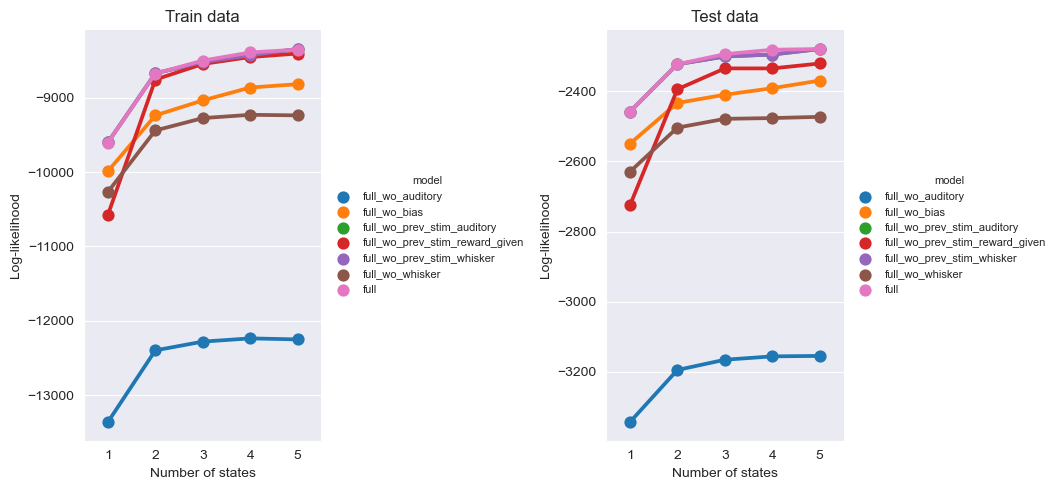

In [105]:
# Plot log likelihood 
fig, axs = plt.subplots(1, 2, figsize=(10, 5), dpi=100)

# Train data
axs[0].set_title('Train data')
sns.pointplot(x='n_states', y='ll_train_final', data=all_models_res_df, ax=axs[0], estimator=np.mean, errorbar='sd',
              hue='model_type')
axs[0].set_ylabel('Log-likelihood')
axs[0].set_xlabel('Number of states')

# Test data
axs[1].set_title('Test data')
sns.pointplot(x='n_states', y='ll_test', data=all_models_res_df, ax=axs[1], estimator=np.mean, errorbar='sd',
              hue='model_type')
axs[1].set_ylabel('Log-likelihood')
axs[1].set_xlabel('Number of states')

for ax in axs.flat:
    remove_top_right_frame(ax)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', title='model', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8, title_fontsize=8)


fig.tight_layout()
plt.subplots_adjust(wspace=1.2)
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name='models_ll', 
                     suffix=None, file_types=['png', 'svg'], dpi=200)


#### Plots predictive accuracy

C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated a

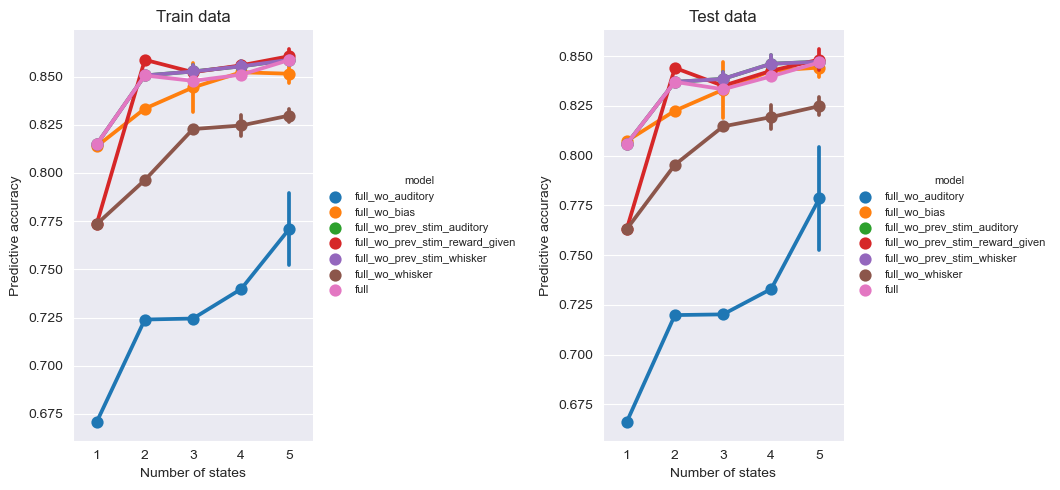

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), dpi=100)

# Train data
axs[0].set_title('Train data')
sns.pointplot(x='n_states', y='predictive_acc_train', data=all_models_res_df, ax=axs[0], estimator=np.mean, errorbar='sd',
              hue='model_type')
axs[0].set_ylabel('Predictive accuracy')
axs[0].set_xlabel('Number of states')

# Test data
axs[1].set_title('Test data')
sns.pointplot(x='n_states', y='predictive_acc_test', data=all_models_res_df, ax=axs[1], estimator=np.mean, errorbar='sd',
              hue='model_type')
axs[1].set_ylabel('Predictive accuracy')
axs[1].set_xlabel('Number of states')

for ax in axs.flat:
    remove_top_right_frame(ax)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', title='model', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8, title_fontsize=8)


fig.tight_layout()
plt.subplots_adjust(wspace=1.2)
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name='models_pred_acc', 
                     suffix=None, file_types=['png', 'svg'], dpi=200)



#### Plots performance in bits per trial

In [179]:
# Convert log-likelihood to bits per trial
def ll_to_bpt(ll, ll_null, n_trials):
    return (ll - ll_null) / (np.log(2) * n_trials)

# Get total  number of trials
print(all_models_res_df.columns)
n_trials_train = all_models_res_df.loc[0, 'output_train_preds:'][0].values[0]
n_trials_train = sum([np.array(i).shape[0] for i in n_trials_train])

n_trials_test = all_models_res_df.loc[0, 'output_test_preds'][0].values[0]
n_trials_test = sum([np.array(i).shape[0] for i in n_trials_test])

# Now make a Bernouille coin-flip model using lick probablility
# This is the null model
p_lick_train = all_models_res_df.loc[0, 'output_train_preds:'][0].values[0]
p_lick_train = np.mean([np.mean(i) for i in p_lick_train])
print('p_lick_train', p_lick_train)
# Calculate log-likelihood of the null model
ll_null_train = np.log(p_lick_train) * n_trials_train + np.log(1 - p_lick_train) * n_trials_train
ll_null_test = np.log(p_lick_train) * n_trials_test + np.log(1 - p_lick_train) * n_trials_test
print('ll_null_train', ll_null_train)
print('ll_null_test', ll_null_test)

# Convert log-likelihood to bits per trial
all_models_res_df['bpt_train'] = all_models_res_df['ll_train_final'].apply(lambda x: ll_to_bpt(x, ll_null_train, n_trials_train))
all_models_res_df['bpt_test'] = all_models_res_df['ll_test'].apply(lambda x: ll_to_bpt(x, ll_null_test, n_trials_test))

# TODO: get ground truth from the data to compute lick rate
# TODO: check the Bernouilli null model formulation
# Do this for each dataset split?


Index(['split_idx', 'n_states', 'instance_idx', 'features', 'weights',
       'transition_matrix', 'll_train', 'll_test', 'output_train_preds:',
       'output_test_preds', 'predictive_acc_train', 'predictive_acc_test',
       'model_type', 'll_train_final'],
      dtype='object')
p_lick_train 0.27569767571637144
ll_null_train -34649.318964657956
ll_null_test -8660.71874437424


C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated a

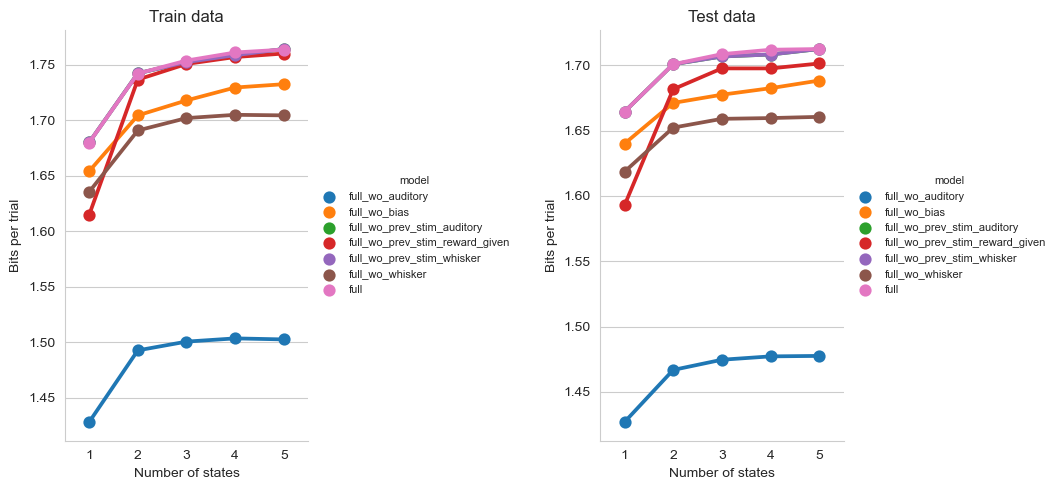

In [181]:
# Plot bits per trial
fig, axs = plt.subplots(1, 2, figsize=(10, 5), dpi=100)

# Train data
axs[0].set_title('Train data')
sns.pointplot(x='n_states', y='bpt_train', data=all_models_res_df, ax=axs[0], estimator=np.mean, errorbar='sd',
              hue='model_type')
axs[0].set_ylabel('Bits per trial')
axs[0].set_xlabel('Number of states')

# Test data
axs[1].set_title('Test data')
sns.pointplot(x='n_states', y='bpt_test', data=all_models_res_df, ax=axs[1], estimator=np.mean, errorbar='sd',
              hue='model_type')
axs[1].set_ylabel('Bits per trial')
axs[1].set_xlabel('Number of states')

for ax in axs.flat:
    remove_top_right_frame(ax)
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    ax.legend(loc='center left', title='model', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8, title_fontsize=8)
    
fig.tight_layout()
plt.subplots_adjust(wspace=1.2)
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name='models_bpt', 
                     suffix=None, file_types=['png', 'svg'], dpi=200)

#### Plot global model weights


Plot model weights of a selected model type

In [91]:
# Select model type
all_models_res_df_full = all_models_res_df[all_models_res_df['model_type'] == 'full']

# For each number of states, plots weights of all states
all_weights_df = []
print('Number of states unique', all_models_res_df_full.n_states.unique())
for n_state_idx in all_models_res_df_full.n_states.unique():
    print('# states', n_state_idx)
    sub_df = all_models_res_df_full[all_models_res_df_full['n_states']==n_state_idx]
    
    # Get weights
    weights_df = sub_df[['split_idx','weights','features']]
    weights_df.loc[:,'n_states'] = n_state_idx
    # Flatten weight array from 3d to 1d
    weights_df.loc[:, 'weights'] = weights_df['weights'].apply(lambda x: np.array(x.flatten()))
    weights_df.loc[:, 'features'] = weights_df['features'].apply(lambda x: x * n_state_idx) # repeat content of features
    # Explode columns jointly now that they match in size
    weights_df = weights_df.explode(['weights','features']).reset_index(drop=True)
    
    # Create a state_idx column
    n_splits, n_features = weights_df['split_idx'].nunique(), weights_df['features'].nunique()
    state_pattern = np.concatenate([np.full(n_features, i) for i in range(n_state_idx)])
    weights_df['state_idx'] = np.tile(state_pattern, n_splits)
    
    # Add to list
    all_weights_df.append(weights_df)
    
# Make dataframe
all_weights_df = pd.concat(all_weights_df)

Number of states unique [1 2 3 4 5]
# states 1
# states 2
# states 3
# states 4
# states 5


C:\Users\bisi\AppData\Local\Temp\ipykernel_33324\2384534320.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weights_df.loc[:,'n_states'] = n_state_idx
C:\Users\bisi\AppData\Local\Temp\ipykernel_33324\2384534320.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weights_df.loc[:,'n_states'] = n_state_idx
C:\Users\bisi\AppData\Local\Temp\ipykernel_33324\2384534320.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

#### Permute states based on highest auditory weight value

In [92]:
# Find index of states with highest auditory weight in absolute values, for each split and number of states
highest_auditory_state = all_weights_df[all_weights_df.features=='auditory'].groupby(['split_idx','n_states']).apply(lambda x: x.loc[x.weights.abs().idxmax()]['state_idx']).reset_index(name='high_aud_state_idx')
all_weights_df = all_weights_df.merge(highest_auditory_state, on=['split_idx','n_states']) # merge dataframes
all_weights_df
TODO: generalize permutation to more than two states...
# If state_idx and high_aud_state_idx are different, then the state is the highest auditory state
all_weights_df['permuted_state_idx'] = all_weights_df.apply(lambda x: 1 if (x['state_idx']==0)&(x['high_aud_state_idx']==1) else(1 if (x['state_idx']==1)&(x['high_aud_state_idx']==0) else 0) , axis=1)

In [93]:
all_weights_df

,split_idx,weights,features,n_states,state_idx,high_aud_state_idx,permuted_state_idx
0,0,-0.881486,bias,1,0,0,0
1,0,-2.321876,auditory,1,0,0,0
2,0,0.26303,prev_stim_auditory,1,0,0,0
3,0,-0.674805,whisker,1,0,0,0
4,0,-0.263029,prev_stim_whisker,1,0,0,0
...,...,...,...,...,...,...,...
895,9,-2.486961,auditory,5,4,3,0
896,9,0.032959,prev_stim_auditory,5,4,3,0
897,9,-0.99642,whisker,5,4,3,0
898,9,-0.032959,prev_stim_whisker,5,4,3,0


C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated a

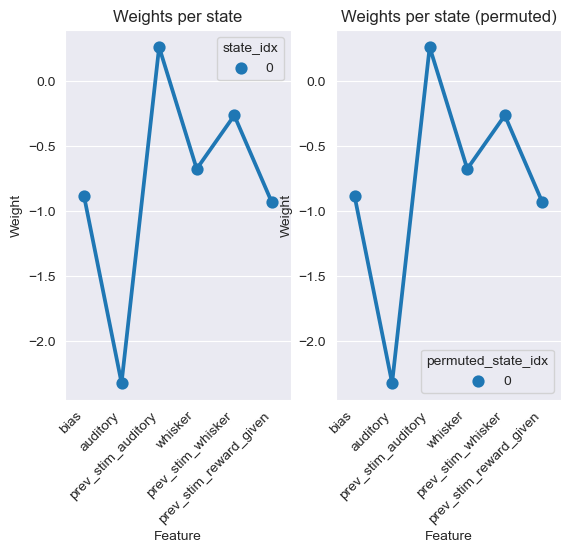

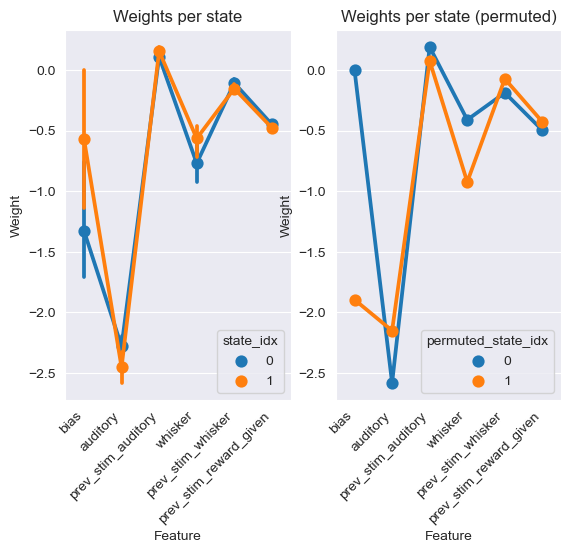

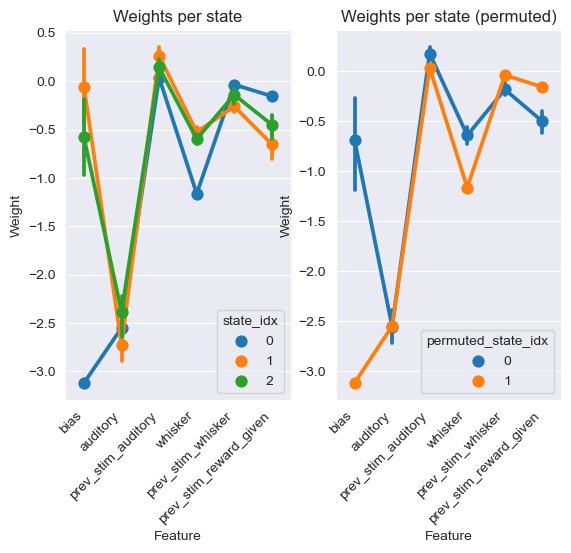

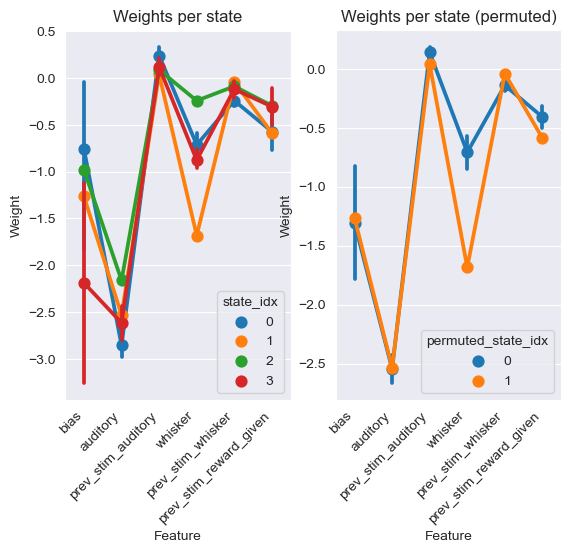

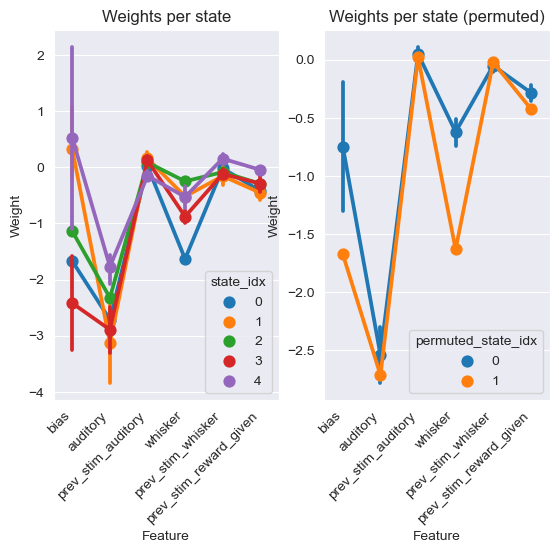

In [97]:
# Plot weights

for n_state_idx in all_weights_df['n_states'].unique():
    
    # Make figure,
    fig, ax = plt.subplots(1,2)
    sns.pointplot(data=all_weights_df[all_weights_df.n_states==n_state_idx],
                  ax=ax[0],
                  x='features',
                  y='weights',
                  hue='state_idx')
    ax[0].set_title('Weights per state')
    ax[0].set_ylabel('Weight')
    ax[0].set_xlabel('Feature')
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, horizontalalignment='right')
    
    sns.pointplot(data=all_weights_df[all_weights_df.n_states==n_state_idx],
                  ax=ax[1],
                  x='features',
                  y='weights',
                  hue='permuted_state_idx')
    ax[1].set_title('Weights per state (permuted)')
    ax[1].set_ylabel('Weight')
    ax[1].set_xlabel('Feature')
    ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, horizontalalignment='right')
    

#### Inspect weights for a specific splits


C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated a

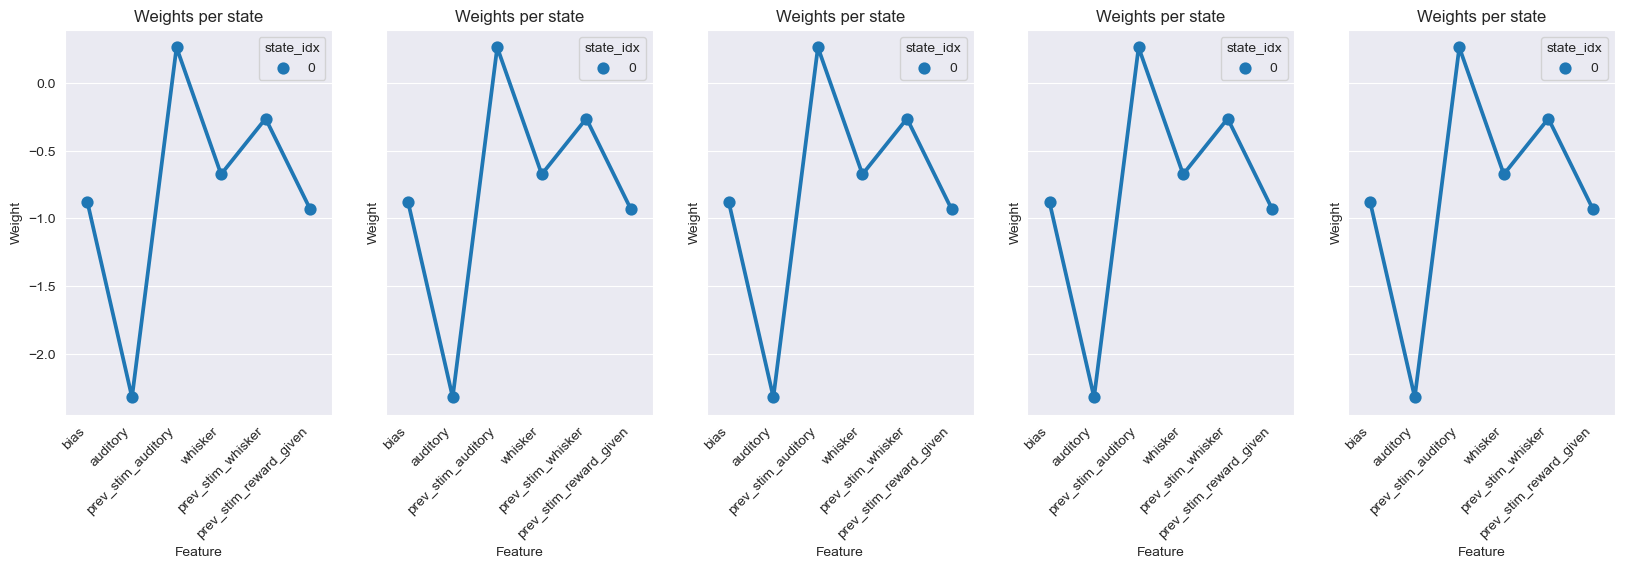

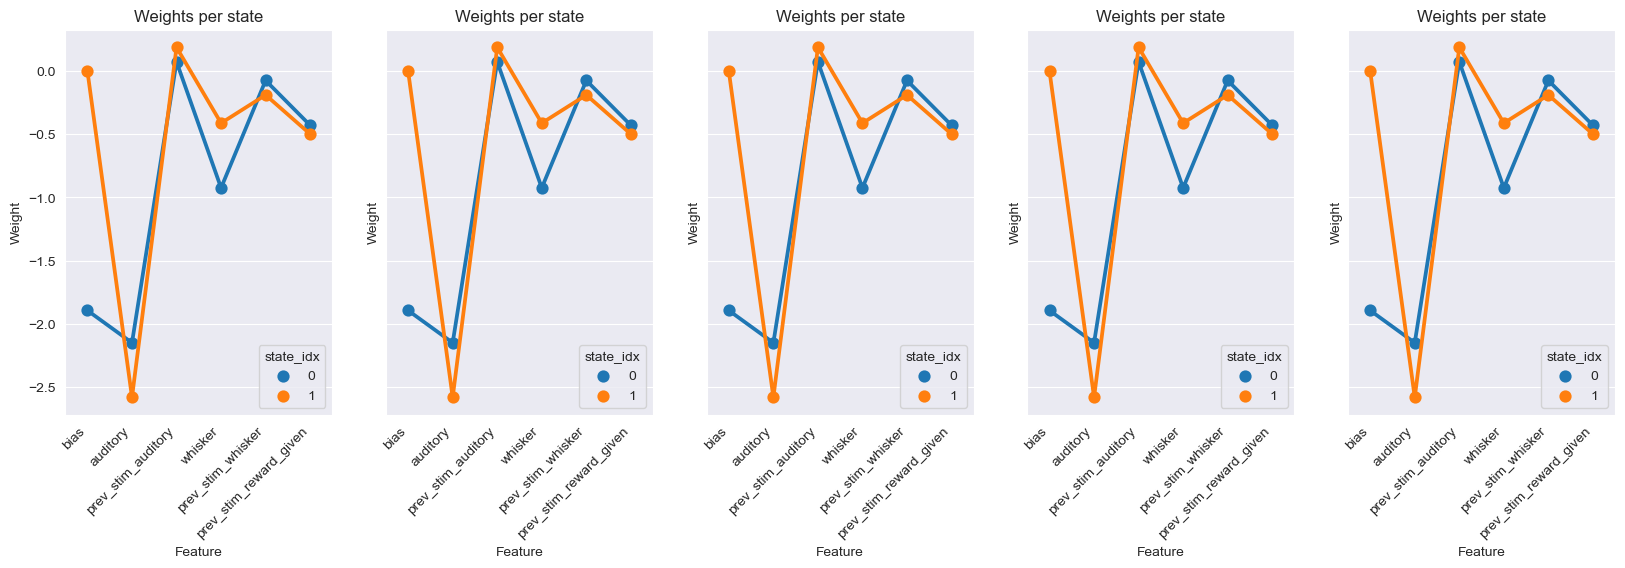

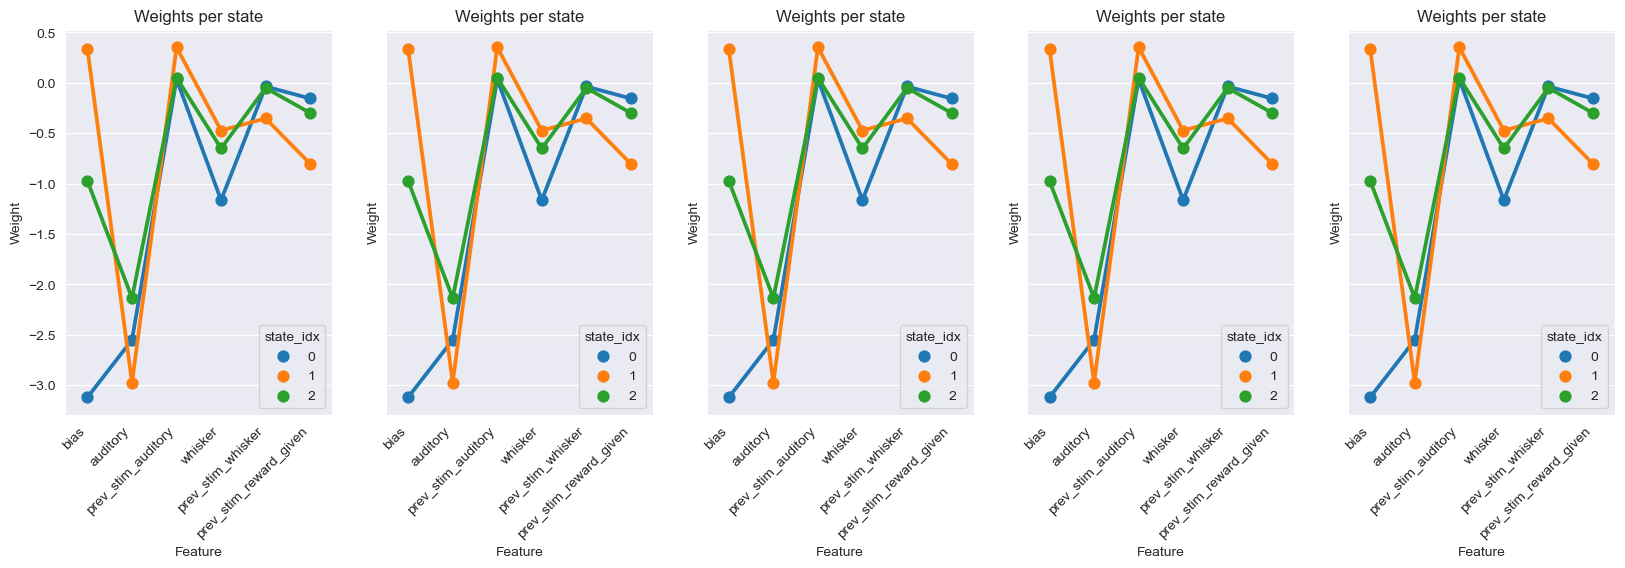

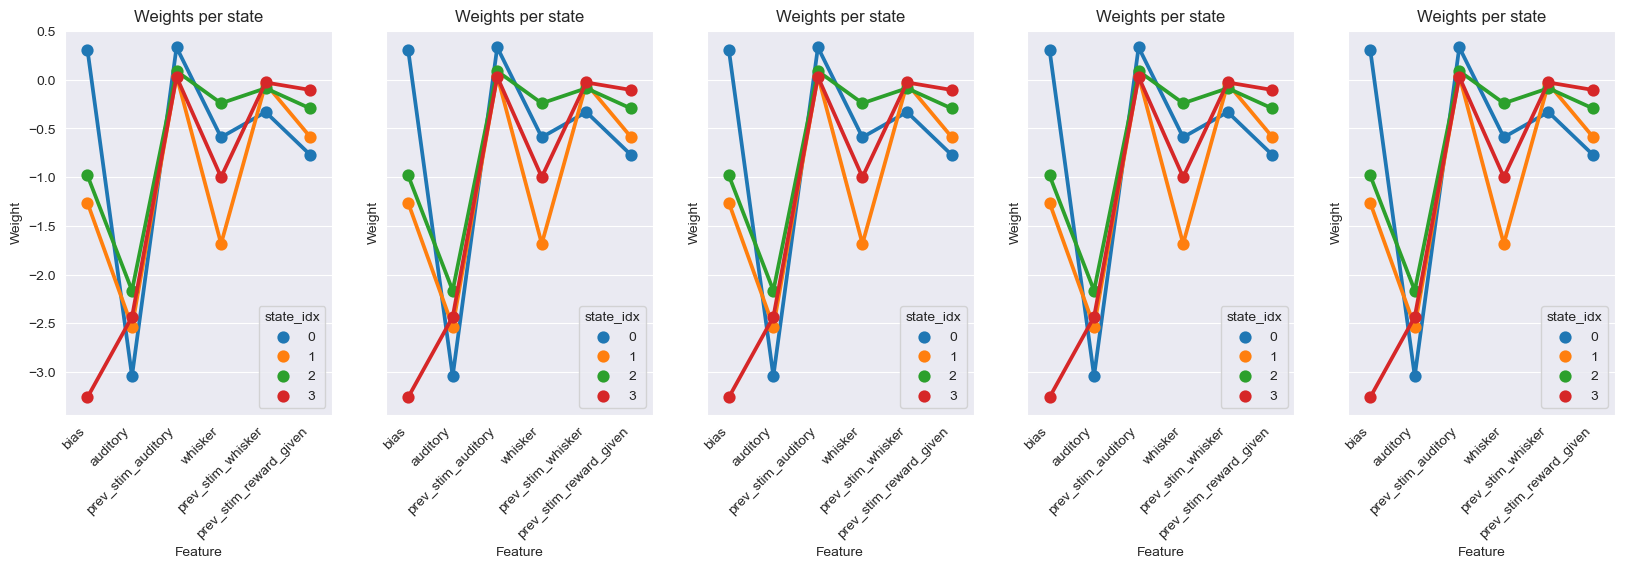

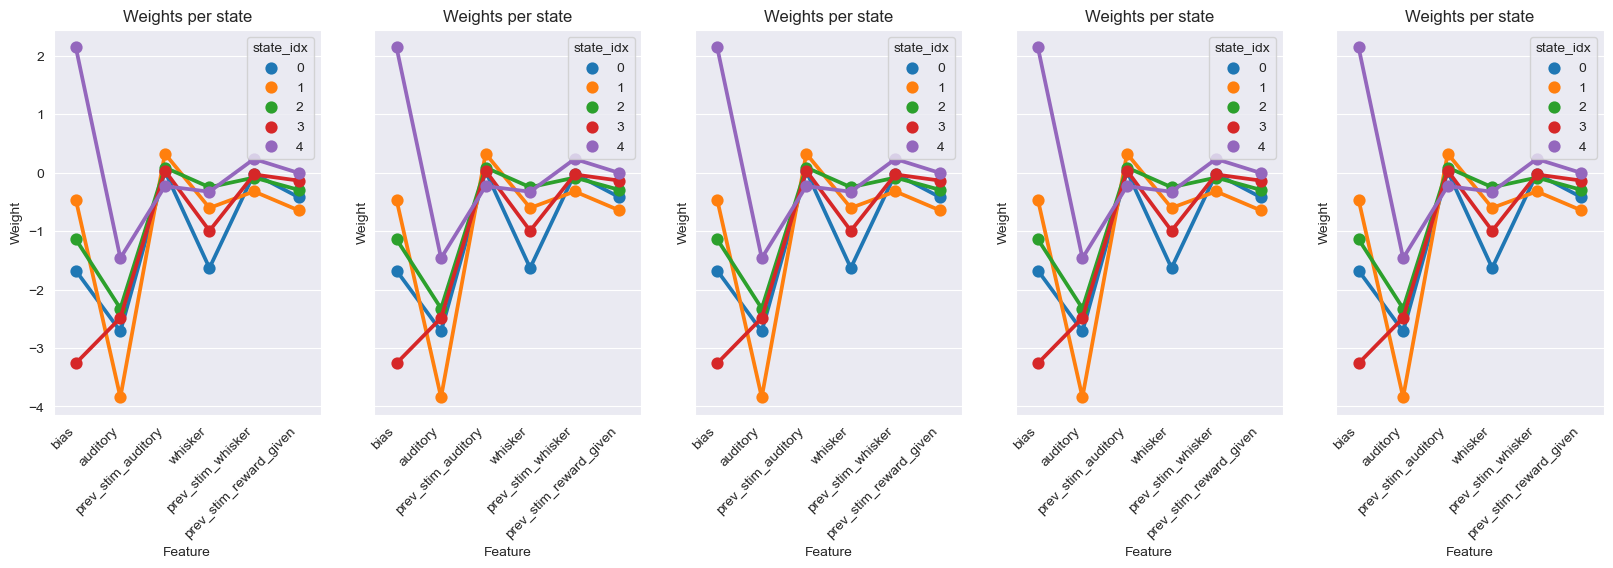

In [104]:
# Plot weights for a specific split
features_to_plot = ['bias', 'auditory', 'whisker']
features_to_plot = all_weights_df['features'].unique()

for n_state_idx in all_weights_df['n_states'].unique():
    
    # Make figure,
    fig, axs = plt.subplots(1,5, sharex=True, sharey=True, figsize=(20, 5))
    for split_idx, ax in enumerate(axs.flat):
        
        sns.pointplot(data=all_weights_df[(all_weights_df.n_states==n_state_idx)&(all_weights_df.split_idx==split_idx)],
                      ax=ax,
                      x='features',
                      order=features_to_plot,
                      y='weights',
                      hue='state_idx')
        ax.set_title('Weights per state')
        ax.set_ylabel('Weight')
        ax.set_xlabel('Feature')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

    